
BFS
Path: ['0', '8', '9']
Length: 3
Nodes explored: 4
Time: 1.1e-05 seconds

DFS
Path: ['0', '5', '3', '9']
Length: 4
Nodes explored: 6
Time: 1e-05 seconds

Bi-BFS
Path: ['0', '8', '9']
Length: 3
Nodes explored: 2
Time: 8e-06 seconds


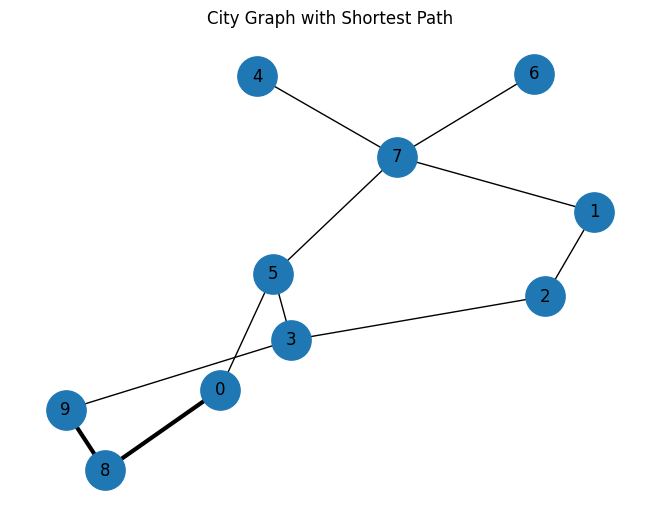

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
import time
import random

def create_city_graph():
    G = nx.Graph()
    nodes = [str(i) for i in range(10)]
    G.add_nodes_from(nodes)

    for _ in range(15):
        a, b = random.sample(nodes, 2)
        G.add_edge(a, b)

    return G




def bfs(graph, start, goal):
    queue = deque([[start]])
    visited = set([start])
    explored = 0

    while queue:
        path = queue.popleft()
        node = path[-1]
        explored += 1

        if node == goal:
            return path, explored

        for neighbor in graph.neighbors(node):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(path + [neighbor])

    return None, explored



def dfs(graph, start, goal):
    stack = [[start]]
    visited = set([start])
    explored = 0

    while stack:
        path = stack.pop()
        node = path[-1]
        explored += 1

        if node == goal:
            return path, explored

        for neighbor in graph.neighbors(node):
            if neighbor not in visited:
                visited.add(neighbor)
                stack.append(path + [neighbor])

    return None, explored



def bidirectional_bfs(graph, start, goal):
    if start == goal:
        return [start], 1

    q_start = deque([[start]])
    q_goal = deque([[goal]])

    visited_start = {start: [start]}
    visited_goal = {goal: [goal]}

    explored = 0

    while q_start and q_goal:

        path = q_start.popleft()
        node = path[-1]
        explored += 1

        for neighbor in graph.neighbors(node):
            if neighbor not in visited_start:
                new_path = path + [neighbor]
                visited_start[neighbor] = new_path
                q_start.append(new_path)

                if neighbor in visited_goal:
                    return new_path + visited_goal[neighbor][::-1][1:], explored

        path = q_goal.popleft()
        node = path[-1]
        explored += 1

        for neighbor in graph.neighbors(node):
            if neighbor not in visited_goal:
                new_path = path + [neighbor]
                visited_goal[neighbor] = new_path
                q_goal.append(new_path)

                if neighbor in visited_start:
                    return visited_start[neighbor] + new_path[::-1][1:], explored

    return None, explored


def compare_algorithms(graph, start, goal):
    for name, func in [("BFS", bfs), ("DFS", dfs), ("Bi-BFS", bidirectional_bfs)]:
        t0 = time.time()
        path, explored = func(graph, start, goal)
        t1 = time.time()

        print(f"\n{name}")
        print("Path:", path)
        print("Length:", len(path))
        print("Nodes explored:", explored)
        print("Time:", round(t1 - t0, 6), "seconds")


def visualize_graph(graph, path=None):
    pos = nx.spring_layout(graph)
    nx.draw(graph, pos, with_labels=True, node_size=800)

    if path:
        edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(graph, pos, edgelist=edges, width=3)

    plt.title("City Graph with Shortest Path")
    plt.show()
if __name__ == "__main__":
    G = create_city_graph()
    start, goal = "0", "9"

    compare_algorithms(G, start, goal)

    path, _ = bidirectional_bfs(G, start, goal)
    visualize_graph(G, path)
